In [1]:
import torch
import mylib
from torch.utils import data

from torch import nn

In [42]:
net = nn.Sequential(
    nn.Conv2d(1, 10, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(10, 16, kernel_size=3), nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 6 * 6, 120), nn.ReLU(),
    nn.Linear(120, 84), nn.ReLU(),
    nn.Linear(84, 10)
)

loss 0.434, train acc 0.838, test acc 0.807
41174.8 example/sec on cuda:0


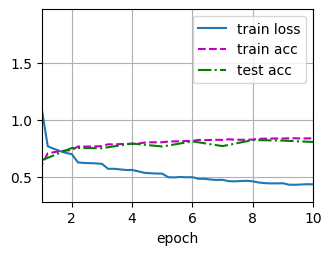

In [43]:
batch_size = 256
train_iter, test_iter = mylib.load_data_fashion_mnist(batch_size)

lr, num_epochs = 0.03, 10
mylib.train(net, train_iter, test_iter, num_epochs, lr, mylib.try_gpu())

array([<AxesSubplot: title={'center': 'input'}>,
       <AxesSubplot: title={'center': 'input'}>,
       <AxesSubplot: title={'center': 'input'}>,
       <AxesSubplot: title={'center': 'input'}>,
       <AxesSubplot: title={'center': 'input'}>,
       <AxesSubplot: title={'center': 'input'}>,
       <AxesSubplot: title={'center': 'input'}>,
       <AxesSubplot: title={'center': 'input'}>], dtype=object)

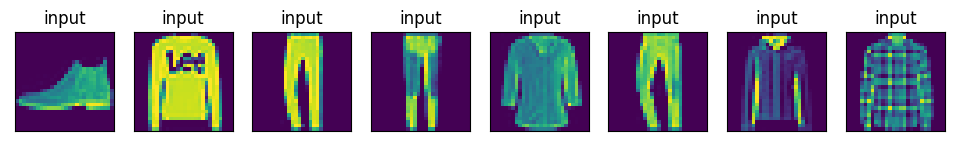

In [40]:
# 显示图像
batch_size = 8
_, test_iter = mylib.load_data_fashion_mnist(batch_size)
X, _ = (next(iter(test_iter)))
mylib.show_images(X.reshape(8, 28, 28), 1, 8, titles=['input'] * 8)

torch.Size([8, 1, 28, 28])
torch.Size([8, 10, 28, 28])
torch.Size([8, 16, 12, 12])


array([<AxesSubplot: title={'center': '2nd ReLU'}>,
       <AxesSubplot: title={'center': '2nd ReLU'}>,
       <AxesSubplot: title={'center': '2nd ReLU'}>,
       <AxesSubplot: title={'center': '2nd ReLU'}>,
       <AxesSubplot: title={'center': '2nd ReLU'}>,
       <AxesSubplot: title={'center': '2nd ReLU'}>,
       <AxesSubplot: title={'center': '2nd ReLU'}>,
       <AxesSubplot: title={'center': '2nd ReLU'}>], dtype=object)

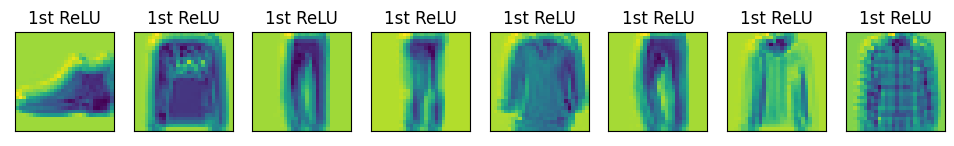

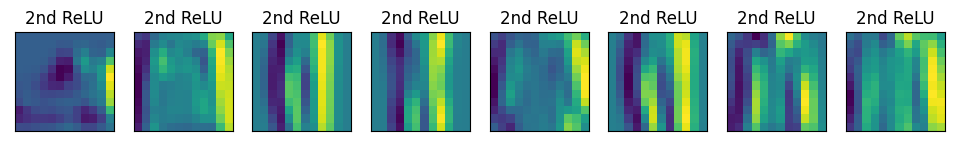

In [41]:
device = mylib.try_gpu()
X = X.to(device)
print(X.shape)
X1 = net[:1](X).to('cpu')
print(X1.shape)
mylib.show_images(X1[:, 0, :, :].detach(), 1, 8, titles=['1st ReLU'] * 8)
X2 = net[:4](X).to('cpu')
print(X2.shape)
mylib.show_images(X2[:, 0, :, :].detach(), 1, 8, titles=['2nd ReLU'] * 8)

In [38]:
## 维数测试
#device = mylib.try_gpu()
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
#X = X.to(device)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, "output shape:\t \t", X.shape)

Conv2d output shape:	 	 torch.Size([1, 10, 28, 28])
ReLU output shape:	 	 torch.Size([1, 10, 28, 28])
MaxPool2d output shape:	 	 torch.Size([1, 10, 14, 14])
Conv2d output shape:	 	 torch.Size([1, 16, 12, 12])
ReLU output shape:	 	 torch.Size([1, 16, 12, 12])
AvgPool2d output shape:	 	 torch.Size([1, 16, 6, 6])
Conv2d output shape:	 	 torch.Size([1, 32, 6, 6])
ReLU output shape:	 	 torch.Size([1, 32, 6, 6])
AvgPool2d output shape:	 	 torch.Size([1, 32, 3, 3])
Flatten output shape:	 	 torch.Size([1, 288])
Linear output shape:	 	 torch.Size([1, 120])
ReLU output shape:	 	 torch.Size([1, 120])
Linear output shape:	 	 torch.Size([1, 84])
ReLU output shape:	 	 torch.Size([1, 84])
Linear output shape:	 	 torch.Size([1, 10])
